# Main Notebook for Inference on Z Boson Mass from data

In [1]:
# Importing Libraries
import numpy as np 
import matplotlib.pyplot as plt
from dynesty import plotting as dyplot

# Importing data and model
from src.reconstruction import m_inv_mass2
from src.reconstruction import e_inv_mass2
from src.model import model

ModuleNotFoundError: No module named 'src'

## Basic histogram plots of invariant masses

In [ ]:
# Plotting histogram of muon invariant mass
fig, ax = plt.subplots(figsize=(9,5))
ax.bar(bin_centers_arr, m_inv_mass2, width=width, alpha=0.5, label="Data")
ax.set_xlabel("Invariant mass [GeV]", fontsize=14)
ax.set_ylabel("Counts per bin", fontsize=14)
ax.legend(fontsize=12)
fig.suptitle("MCMC Fit to Z Peak Data", fontsize=24, fontweight = 'bold')
fig.tight_layout()
fig.savefig("plots/"+"fit_mcmc.png", dpi=300)
plt.show()


NameError: name 'plt' is not defined

In [ ]:
# Plotting histogram of electron invariant mass
fig, ax = plt.subplots(figsize=(9,5))
ax.bar(bin_centers_arr, e_inv_mass2, width=width, alpha=0.5, label="Data")
ax.set_xlabel("Invariant mass [GeV]", fontsize=14) 
ax.set_ylabel("Counts per bin", fontsize=14)
ax.legend(fontsize=12)
fig.suptitle("MCMC Fit to Z Peak Data", fontsize=24, fontweight = 'bold')
fig.tight_layout()
fig.savefig("plots/"+"fit_mcmc.png", dpi=300)
plt.show()

## EMCEE Implementation (Monte Carlo Markov Chain)

In [6]:
# Importing Results from mcmc_fitting
from src.mcmc_fitting import samples as mcmc_samples, bin_edges as mcmc_bin_edges, bin_centers as mcmc_bin_centers, chain as mcmc_chain

best_fit = np.median(mcmc_samples, axis=0)
print(f"Best Fit Parameters (MCMC): {best_fit}")

Best Fit Parameters (MCMC): [9.07338356e+01 1.10398726e+00 1.39720497e+00 1.11353751e+04
 6.70429069e+00]


In [7]:
# Calculating parameter estimates from MCMC samples
param_names = ["m0", "gamma", "sigma", "Nsig", "Nbg"]

# Posterior median + std
median_params = np.median(mcmc_samples, axis=0)
std_params = np.std(mcmc_samples, axis=0)

print("Posterior median ± std (MCMC):")
for name, median, std in zip(param_names, median_params, std_params):
    print(f"{name} = {median:.3f} ± {std:.3f}")


# Credible intervals (16-84%)
q16, q50, q84 = np.percentile(mcmc_samples, [16, 50, 84], axis=0)

print("\nPosterior 16-50-84% credible intervals (MCMC):")
for i, name in enumerate(param_names):
    print(f"{name} = {q50[i]:.3f} +{q84[i]-q50[i]:.3f} -{q50[i]-q16[i]:.3f}")

Posterior median ± std (MCMC):
m0 = 90.734 ± 0.026
gamma = 1.104 ± 0.090
sigma = 1.397 ± 0.081
Nsig = 11135.375 ± 159.474
Nbg = 6.704 ± 0.269

Posterior 16-50-84% credible intervals (MCMC):
m0 = 90.734 +0.026 -0.026
gamma = 1.104 +0.088 -0.092
sigma = 1.397 +0.081 -0.079
Nsig = 11135.375 +158.080 -157.985
Nbg = 6.704 +0.274 -0.263


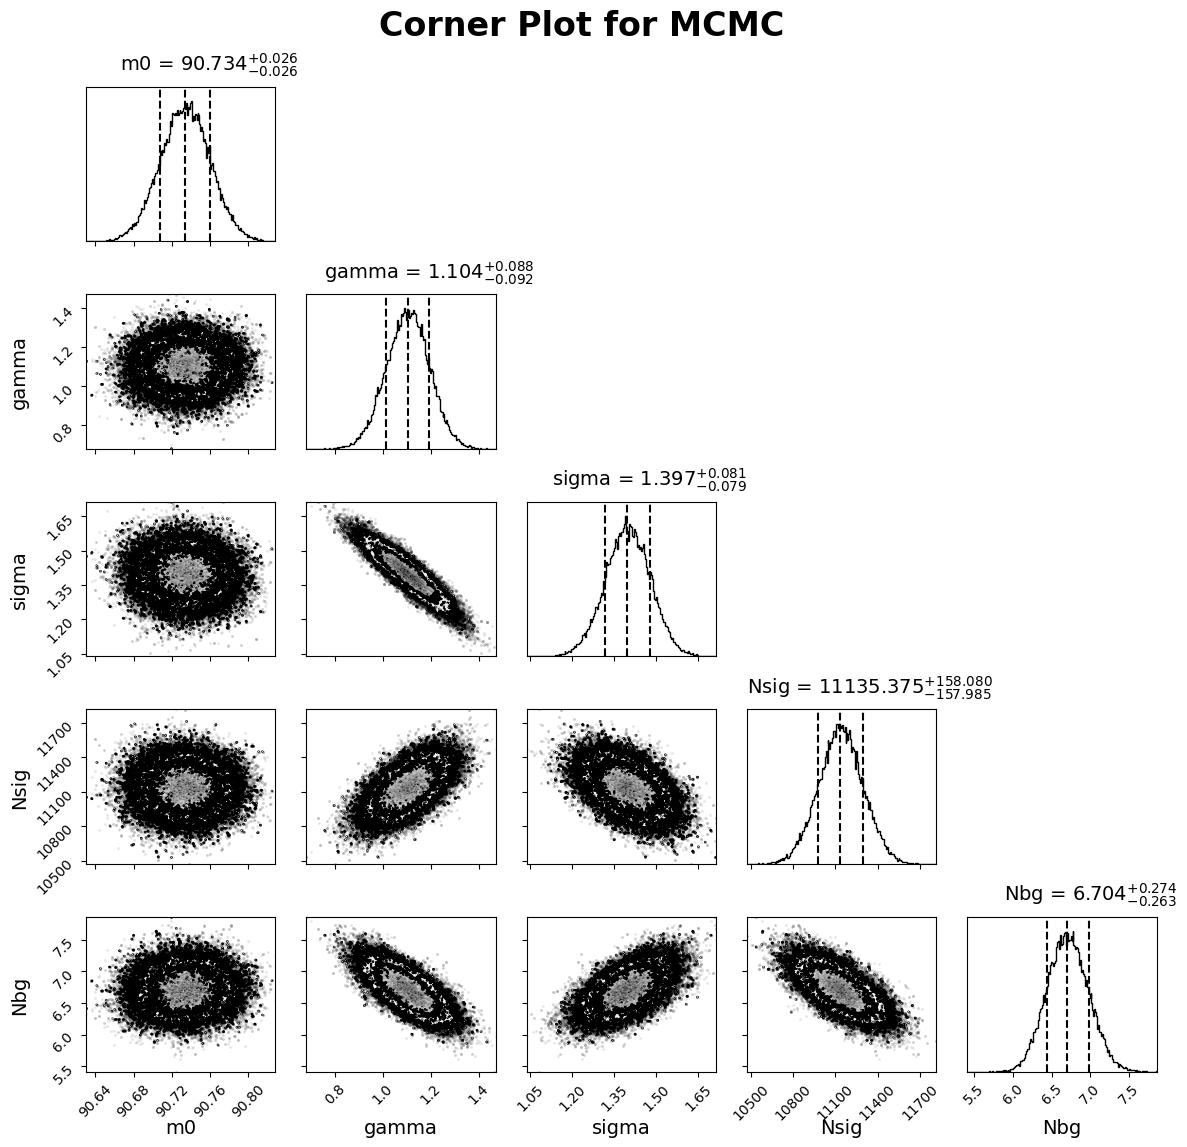

In [8]:
# Corner plot for MCMC

import corner

fig = corner.corner(
    mcmc_samples,
    labels=param_names,
    label_kwargs={"fontsize": 14},
    show_titles=True,
    title_fmt=".3f",
    quantiles=[0.16, 0.5, 0.84],
    levels=[0.68, 0.95],
    smooth= 0.02,
    bins = 200,
    color = 'black',
    title_kwargs={"x": 0.65, "y": 1.05, 'fontsize': 14}
)

fig.suptitle("Corner Plot for MCMC", fontsize=24, fontweight="bold")
fig.tight_layout()
fig.savefig("plots/"+"corner_mcmc.png", dpi=300)
plt.show()

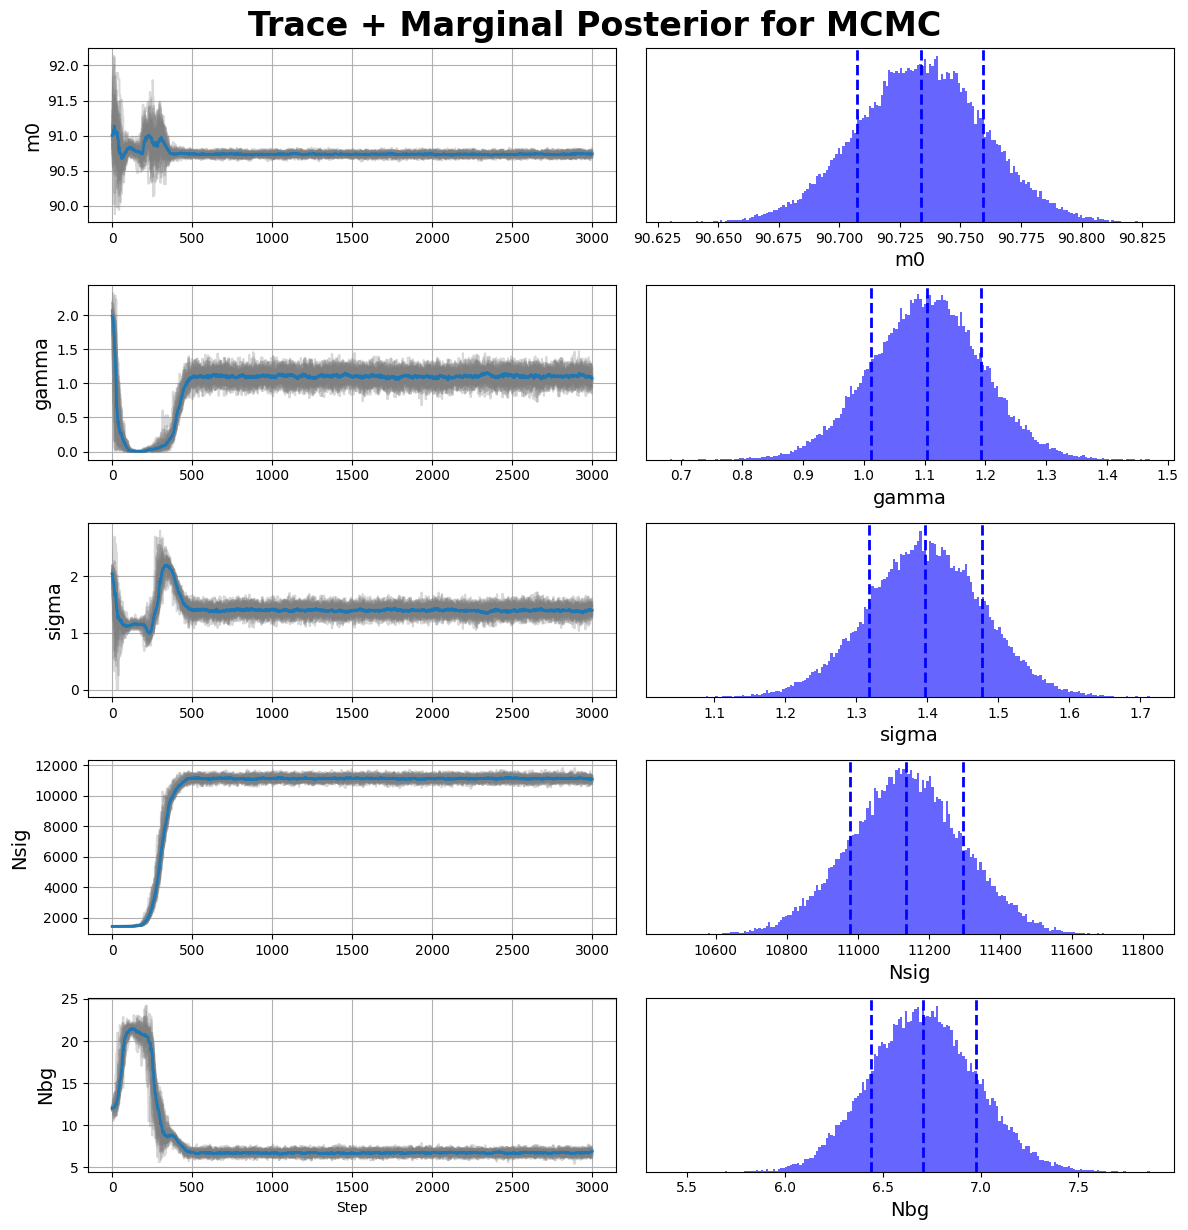

In [9]:
# Trace + Marginal Posterior for MCMC

nsteps, nwalkers, ndim = mcmc_chain.shape
fig, axes = plt.subplots(ndim, 2, figsize=(12, 2.5*ndim), gridspec_kw={'width_ratios': [1, 1]})

for i in range(ndim):
    # Trace of walkers
    ax = axes[i, 0]
    for j in range(nwalkers):
        ax.plot(mcmc_chain[:, j, i], color='gray', alpha=0.3)
    
    median = np.median(mcmc_chain[:, :, i], axis=1)
    lower = np.percentile(mcmc_chain[:, :, i], 16, axis=1)
    upper = np.percentile(mcmc_chain[:, :, i], 84, axis=1)
    
    ax.plot(median, color='C0', lw=2)
    ax.fill_between(np.arange(nsteps), lower, upper, color='C0', alpha=0.2)
    ax.set_ylabel(param_names[i], fontsize = 14)
    ax.grid(True)
    
    # Posterior histogram
    ax_hist = axes[i, 1]
    ax_hist.hist(mcmc_samples[:, i], bins=200, color='blue', alpha=0.6)
    
    # 16%, 50%, 84% quantile lines
    q16, q50, q84 = np.percentile(mcmc_samples[:, i], [16, 50, 84])
    ax_hist.axvline(q16, color='blue', lw=2, ls='--')
    ax_hist.axvline(q50, color='blue', lw=2, ls ='--')
    ax_hist.axvline(q84, color='blue', lw=2, ls='--')
    
    ax_hist.set_yticks([])
    ax_hist.set_xlabel(param_names[i], fontsize=14)

axes[-1, 0].set_xlabel("Step")
fig.suptitle("Trace + Marginal Posterior for MCMC", fontsize=24, fontweight="bold")
plt.tight_layout()
fig.savefig("plots/"+"trace_mcmc.png", dpi=300)
plt.show()

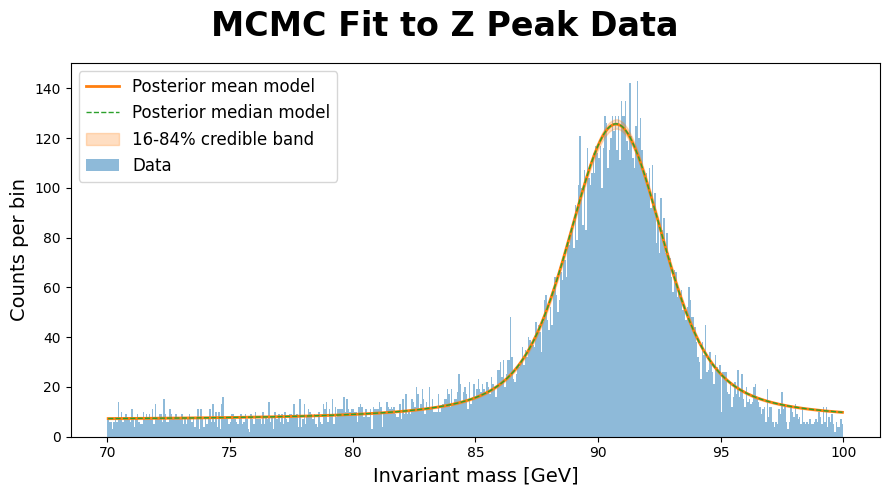

In [10]:
# Plot model with uncertainty band
bin_centers_arr = 0.5 * (mcmc_bin_edges[:-1] + mcmc_bin_edges[1:])
observed_counts, _ = np.histogram(np.sqrt(m_inv_mass2), bins=mcmc_bin_edges)
width = np.diff(mcmc_bin_edges)[0]

# Draw posterior samples to get model envelope
n_draw = 500
indices = np.random.choice(len(mcmc_samples), size=n_draw, replace=True)
models = np.array([model(bin_centers_arr, *mcmc_samples[i]) for i in indices])
lower = np.percentile(models, 16, axis=0)
upper = np.percentile(models, 84, axis=0)
median_model = np.percentile(models, 50, axis=0)
mean_model = np.mean(models, axis=0)

# Plot histogram and model bands
fig, ax = plt.subplots(figsize=(9,5))
ax.bar(bin_centers_arr, observed_counts, width=width, alpha=0.5, label="Data")
ax.plot(bin_centers_arr, mean_model, color='C1', lw=2, label="Posterior mean model")
ax.plot(bin_centers_arr, median_model, color='C2', lw=1, ls='--', label="Posterior median model")
ax.fill_between(bin_centers_arr, lower, upper, color='C1', alpha=0.25, label="16-84% credible band")
ax.set_xlabel("Invariant mass [GeV]", fontsize=14)
ax.set_ylabel("Counts per bin", fontsize=14)
ax.legend(fontsize=12)
fig.suptitle("MCMC Fit to Z Peak Data", fontsize=24, fontweight = 'bold')
fig.tight_layout()
fig.savefig("plots/"+"fit_mcmc.png", dpi=300)
plt.show()

## Dynesty Implementation (Nested Sampling)

In [11]:
# Importing Results from dynesty_fitting
from src.dynesty_fitting import results, bin_edges as dynesty_bin_edges, bin_centers as dynesty_bin_centers

22233it [01:54, 194.93it/s, +1000 | bound: 56 | nc: 1 | ncall: 91733 | eff(%): 25.606 | loglstar:   -inf < 41888.105 <    inf | logz: 41865.785 +/-  0.160 | dlogz:  0.001 >  1.009]


In [28]:
# Histogram of observed data
dynesty_counts, _ = np.histogram(np.sqrt(m_inv_mass2), bins=dynesty_bin_edges)

# Prepare arrays
dynesty_samples = results.samples            # (nsamp, 5): [m0, gamma, sigma, Nsig, Nbg]
print(f"Number of samples: {len(dynesty_samples)}")
logw = results.logwt                 # (nsamp,): log-weights for each sample

# Stable normalized weights
dynesty_weights = np.exp(logw - np.max(logw))
dynesty_weights /= dynesty_weights.sum()

# Calculating parameter estimates from Dynesty samples
param_names = ["m0", "gamma", "sigma", "Nsig", "Nbg"]

# Posterior median + std + mean
median_params = np.median(dynesty_samples, axis=0)
std_params = np.sqrt(np.average((dynesty_samples - median_params)**2, 
                                axis=0, weights=dynesty_weights))
mean_params = np.average(dynesty_samples, axis=0, weights=dynesty_weights)

print("Posterior median ± std ± mean (Dynesty):")
for name, median, std, mean in zip(param_names, median_params, std_params, mean_params):
    print(f"{name} = {median:.3f} ± {std:.3f} ({mean:.3f})")


# Credible intervals (16-84%)
q16, q50, q84 = np.percentile(dynesty_samples, [16, 50, 84], axis=0, 
                            weights=dynesty_weights, method="inverted_cdf")

print("\nPosterior 16-50-84% credible intervals (Dynesty):")
for i, name in enumerate(param_names):
    print(f"{name} = {q50[i]:.3f} +{q84[i]-q50[i]:.3f} -{q50[i]-q16[i]:.3f}")

Number of samples: 23233


Posterior median ± std ± mean (Dynesty):
m0 = 90.732 ± 0.026 (90.732)
gamma = 1.204 ± 0.136 (1.103)
sigma = 1.435 ± 0.089 (1.399)
Nsig = 11057.480 ± 180.038 (11136.842)
Nbg = 6.927 ± 0.345 (6.712)

Posterior 16-50-84% credible intervals (Dynesty):
m0 = 90.733 +0.025 -0.026
gamma = 1.103 +0.090 -0.093
sigma = 1.401 +0.079 -0.082
Nsig = 11135.259 +165.190 -159.140
Nbg = 6.709 +0.268 -0.263


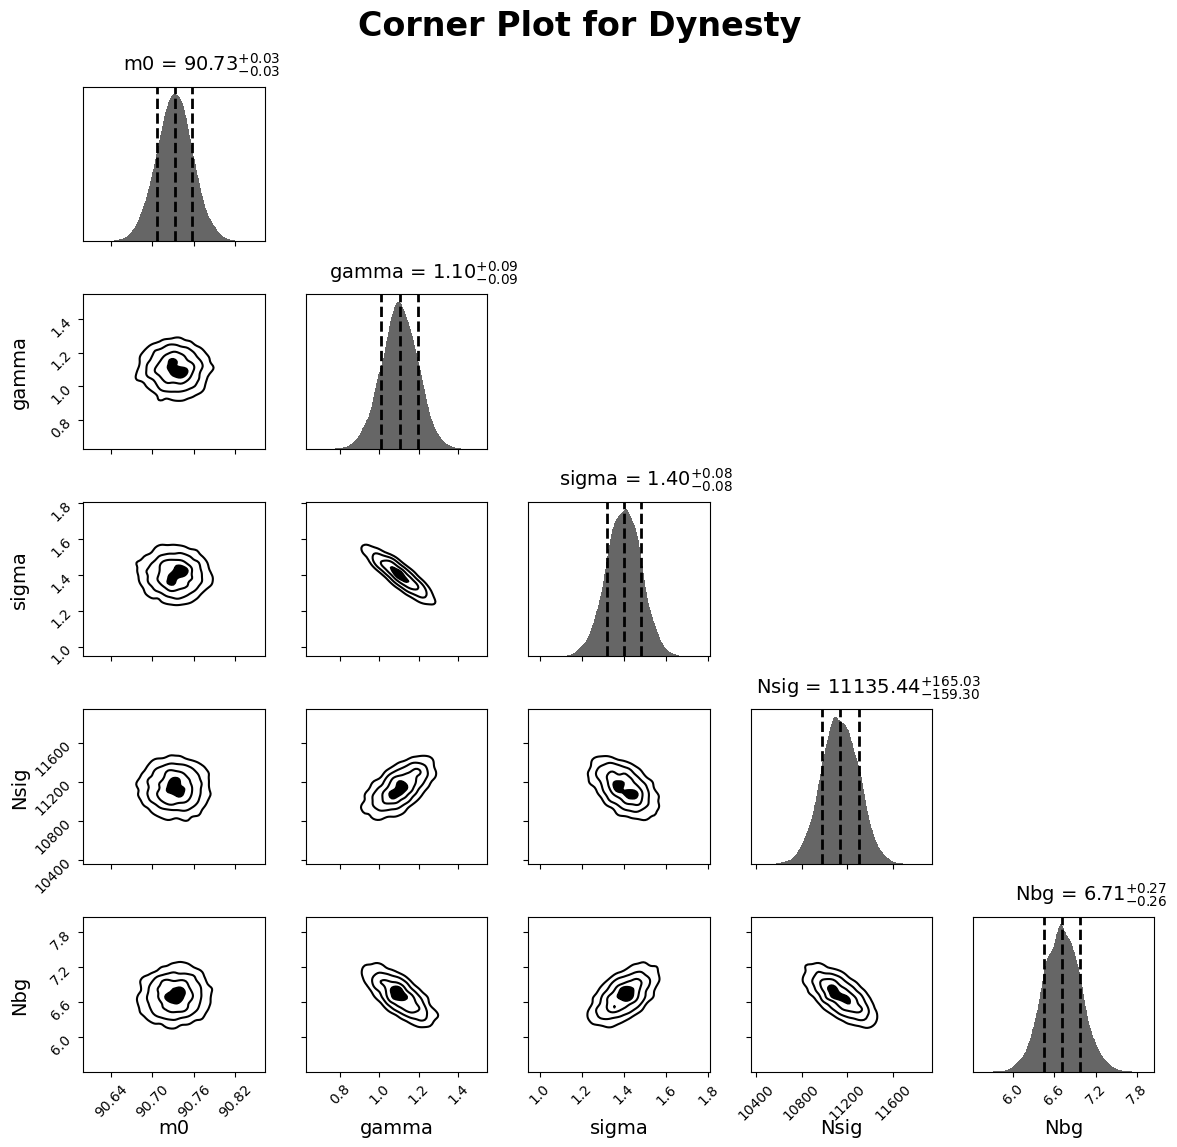

In [13]:
# Corner Plot
param_labels = ['m0', 'gamma', 'sigma', 'Nsig', 'Nbg']
figc, axesc = dyplot.cornerplot(results, 
                                title_quantiles = [0.16, 0.5, 0.84], 
                                quantiles = [0.16, 0.5, 0.84], 
                                show_titles=True, 
                                labels=param_labels,
                                label_kwargs={"fontsize": 14},
                                title_kwargs={"x": 0.65, "y": 1.05, 'fontsize' : 14}, 
                                title_fmt=".2f",
                                smooth=0.02)
figc.suptitle("Corner Plot for Dynesty", fontsize=24, fontweight='bold')
figc.tight_layout()
figc.savefig("plots/"+"corner_dynesty.png", dpi=300)
plt.show()

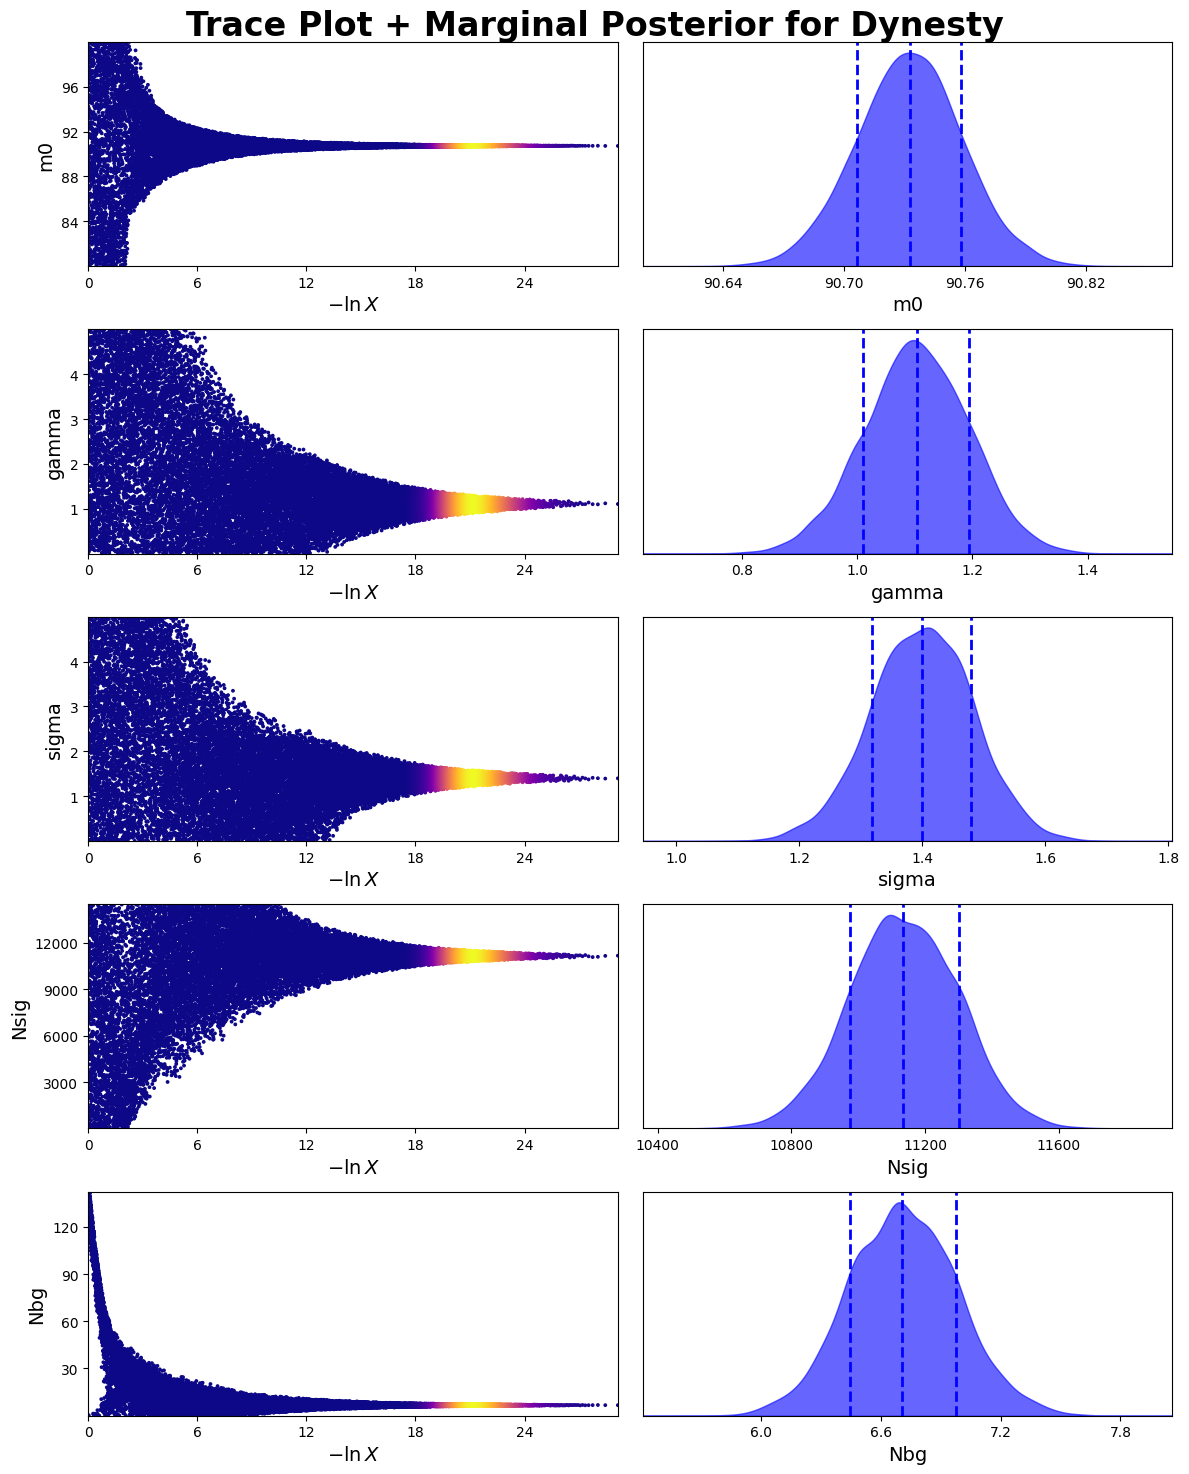

In [14]:
# Trace Plot
figt, axest = dyplot.traceplot(results, 
                               labels=param_labels,
                               label_kwargs={"fontsize": 14},
                               quantiles=[0.16, 0.5, 0.84], 
                               title_kwargs={"x": 0.65, "y": 1.05, 'fontsize': 14})
figt.suptitle("Trace Plot + Marginal Posterior for Dynesty", fontsize=24, fontweight='bold')
figt.tight_layout()
figt.savefig("plots/"+"trace_dynesty.png", dpi=300)
plt.show()

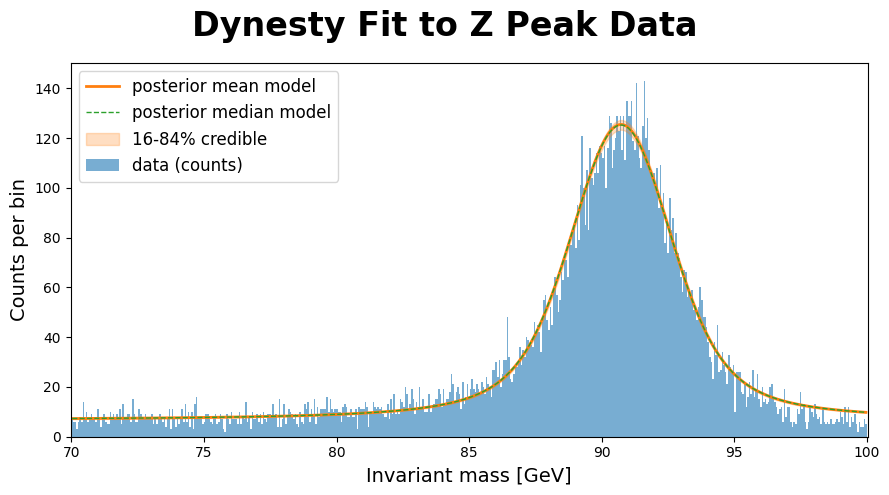

In [16]:
# Uncertainty band from posterior samples (weighted draw)
n_draw = 500
rng = np.random.default_rng(12345)
indices = rng.choice(len(dynesty_samples), size=n_draw, replace=True, p=dynesty_weights)
x = dynesty_bin_centers
obs = dynesty_counts
model_mean = model(x, mean_params[0], mean_params[1], mean_params[2], mean_params[3], mean_params[4])
models = []
for idx in indices:
    p = dynesty_samples[idx]
    # model returns counts per bin directly
    models.append(model(x, p[0], p[1], p[2], p[3], p[4]))
models = np.vstack(models)
lower = np.percentile(models, 16, axis=0)
upper = np.percentile(models, 84, axis=0)
median = np.percentile(models, 50, axis=0)

# Plot the fitted models vs the observed data
fig, ax = plt.subplots(figsize=(9,5))
ax.bar(x, obs, width=width, align='center', alpha=0.6, label='data (counts)')
ax.plot(x, model_mean, color='C1', lw=2, label='posterior mean model')
ax.plot(x, median, color='C2', lw=1, ls='--', label='posterior median model')
ax.fill_between(x, lower, upper, color='C1', alpha=0.25, label='16-84% credible')
ax.set_xlabel('Invariant mass [GeV]', fontsize=14)
ax.set_ylabel('Counts per bin', fontsize=14)
ax.legend(fontsize=12)
ax.set_xlim(x.min() - width, x.max() + width)
fig.suptitle('Dynesty Fit to Z Peak Data', fontsize=24, fontweight='bold')
fig.tight_layout()
fig.savefig("plots/"+"fit_dynesty.png", dpi=300)
plt.show()